Artificial Neural Networks for Predicting Diabetes Likelihood

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.metrics import Precision, AUC
import matplotlib.pyplot as plt

In [2]:
# Importing the clean training and testing dataset

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
# Identify binary columns and continuous columns for scaling as we need to scale only continuous variabels

binary_cols = [c for c in train.columns if set(pd.unique(train[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in train.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),
    ]
)

# Fitting the data (it becomes a scaled array)

train_scaled_array = preprocess.fit_transform(train) 
test_scaled_array = preprocess.transform(test)

# Convert the arrays back into dataframes for data manipulation

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=train.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=test.index)


In [4]:
# Splitting the scaled data into "X" matrix (input) and "Y" matrix (true outcome)
# Dropped Smoking history as it showed little effect in the model from SHAP

train_input = train_scaled[['age', 'bmi','blood_glucose_level', 'male', 'female', 'hypertension','heart_disease']]
train_output = train_scaled[['diabetes']]

test_input = test_scaled[['age', 'bmi', 'blood_glucose_level', 'male', 'female', 'hypertension','heart_disease']]
test_output = test_scaled[['diabetes']]

In [5]:
# Fourth Test:
# Initialising and adding layers: Architecture 7 22 14 1

# Compiling ANN:
# Use "GeLU" for activation
# Use "RMSprop" with default learning rate and modified rho for back propagation optimiser
# Use "binary_crossentropy" for calculating loss in classification problem
# Measure metrics such as "accuracy", "precision", "AUC"
# Changed batch size to 64

ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=22, activation='gelu'))
ann.add(tf.keras.layers.Dense(units=14, activation='gelu'))
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

# Early stopping function, if there is no improvements during 6 consecutive epochs, stop the iteration.

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=6)

opt = tf.keras.optimizers.RMSprop(learning_rate=0.001, rho=0.9)

ann.compile(optimizer=opt, loss="binary_crossentropy", 
            metrics=['accuracy', Precision(), AUC()])

# Fitting ANN, try 100 epochs with early stopping

model = ann.fit(train_input, train_output, batch_size=64, verbose = 0, 
                validation_split = 0.2, epochs = 100, callbacks=[callback])



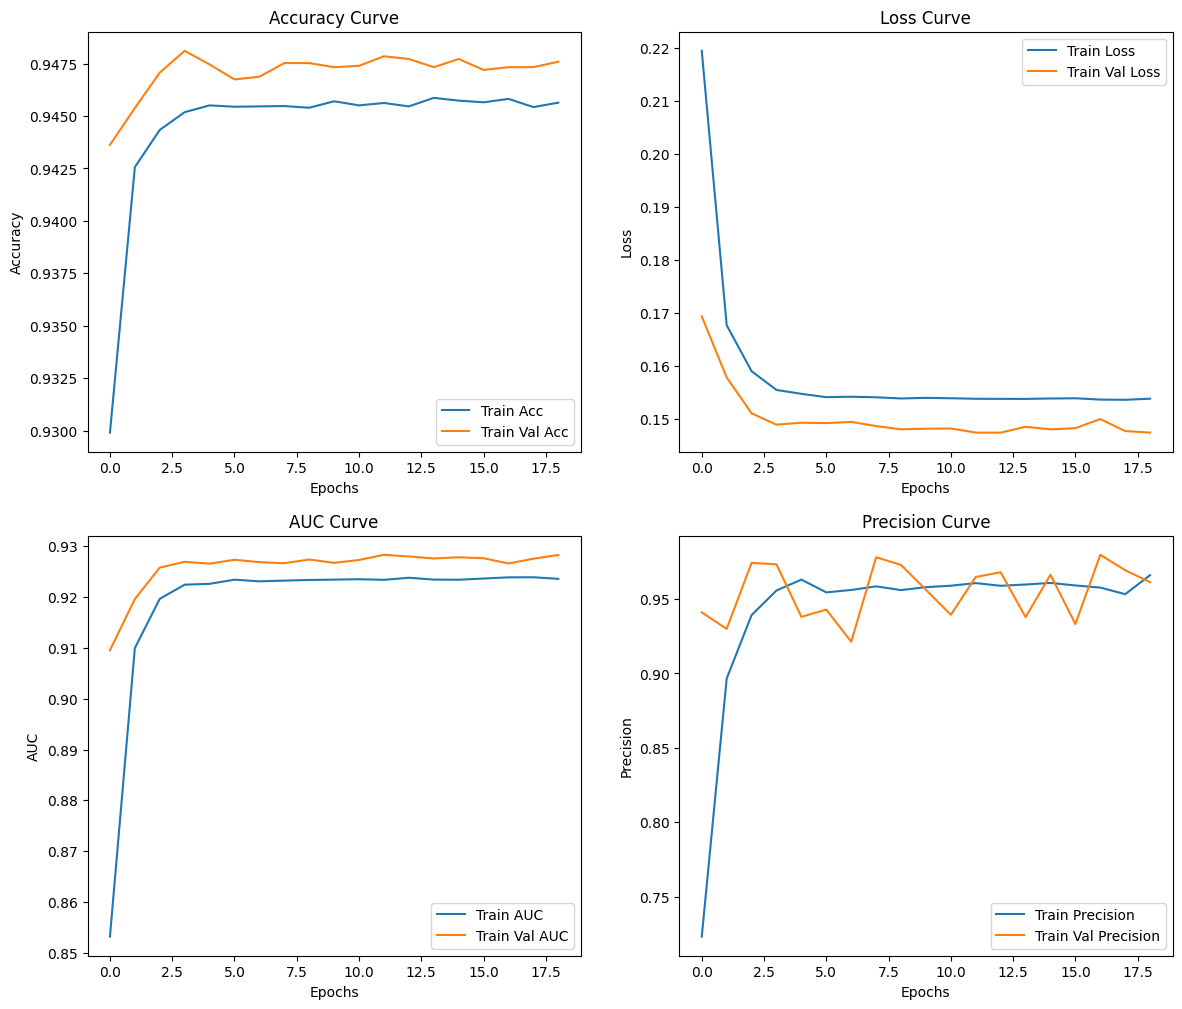

In [6]:
# Plotting Accuracy, Loss, AUC, and Precision in a 2x2 subplot

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

# Accuracy Curve

ax1.plot(model.history['accuracy'], label = 'Train Acc')
ax1.plot(model.history['val_accuracy'], label = 'Train Val Acc')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy Curve")
ax1.legend() 

# Loss Curve

ax2.plot(model.history['loss'], label = 'Train Loss')
ax2.plot(model.history['val_loss'], label = 'Train Val Loss')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.set_title("Loss Curve")
ax2.legend() 

# AUC Curve

ax3.plot(model.history['auc'], label = 'Train AUC')
ax3.plot(model.history['val_auc'], label = 'Train Val AUC')
ax3.set_xlabel("Epochs")
ax3.set_ylabel("AUC")
ax3.set_title("AUC Curve")
ax3.legend() 

# Precision Curve

ax4.plot(model.history['precision'], label = 'Train Precision')
ax4.plot(model.history['val_precision'], label = 'Train Val Precision')
ax4.set_xlabel("Epochs")
ax4.set_ylabel("Precision")
ax4.set_title("Precision Curve")
ax4.legend() 

# Save the plot

# plt.savefig("Training_Metrics_Plot2")

plt.show()


In [7]:
# Evaluate the trained ANN model on the test dataset

ann.evaluate(test_input, test_output)

601/601 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9464 - auc: 0.9278 - loss: 0.1515 - precision: 0.9674


[0.15149523317813873,
 0.9464183449745178,
 0.967391312122345,
 0.9278154373168945]

In [8]:
# Predict diabetes probabilities on the test dataset
# .squeeze() removes extra dimensions so we get a 1D array

y_pred_proba = ann.predict(test_input, verbose=0).squeeze()
y_pred = pd.DataFrame({"diabetes_pred": y_pred_proba}, index = test_output.index)

# Combine actual labels with predicted probabilities for comparison

prediction_binary = pd.concat([test_output, y_pred], axis = 1)

In [ ]:
# Save the predicted and true outcome dataframes into a file for analysis
# Save the training history metrics

# prediction_binary.to_csv("predictions_binary.csv", index=False)

# pd.DataFrame(model.history).to_csv("training_history4.csv", index=False)
